# 问题3. 销量前 50 的 Python 类图书中，哪些出版社的书籍比较多？

**姓名**：刘嘉亮

**学号**：25210193



**分析目的**：明确在畅销Python书籍市场中，哪些出版社占据主流地位。通过出版社的评论数维度，分析不同出版社的Python书籍引发读者讨论、反馈的热度，间接反映书籍内容的受欢迎程度。

提示词:

'''
raw

假设我是一个教师，准备写一本有关 Python 的书籍。在开始之前，我想先了解，在当当网销量排名前 50 的 Python 类户籍的出版社相关数据。
1. 先用文件"D:\GitHub\ex_Team01_group_3\dangdang_python_books_clean.csv"中提取书名、出版社、评论数这三列数据；
2. 绘制出版社变量的条形图，按频率降序排列，在条形顶端标注百分比数值
3. 将同一出版社的评论数加总，按出版社分组，计算每类岗位的通过率，用水平条形图呈现各出版社的评论总数，从高到低排序，并在条形末端标注百分比
4. 分析图表和结果放在D:\GitHub\ex_Team01_group_3\output

'''

分析完成！结果已保存至：D:\GitHub\ex_Team01_group_3\output
1. 出版社频率分布图：出版社频率分布.png
2. 出版社评论总数图：出版社评论总数分布.png
3. 分析结果数据：Python书籍出版社分析结果.csv


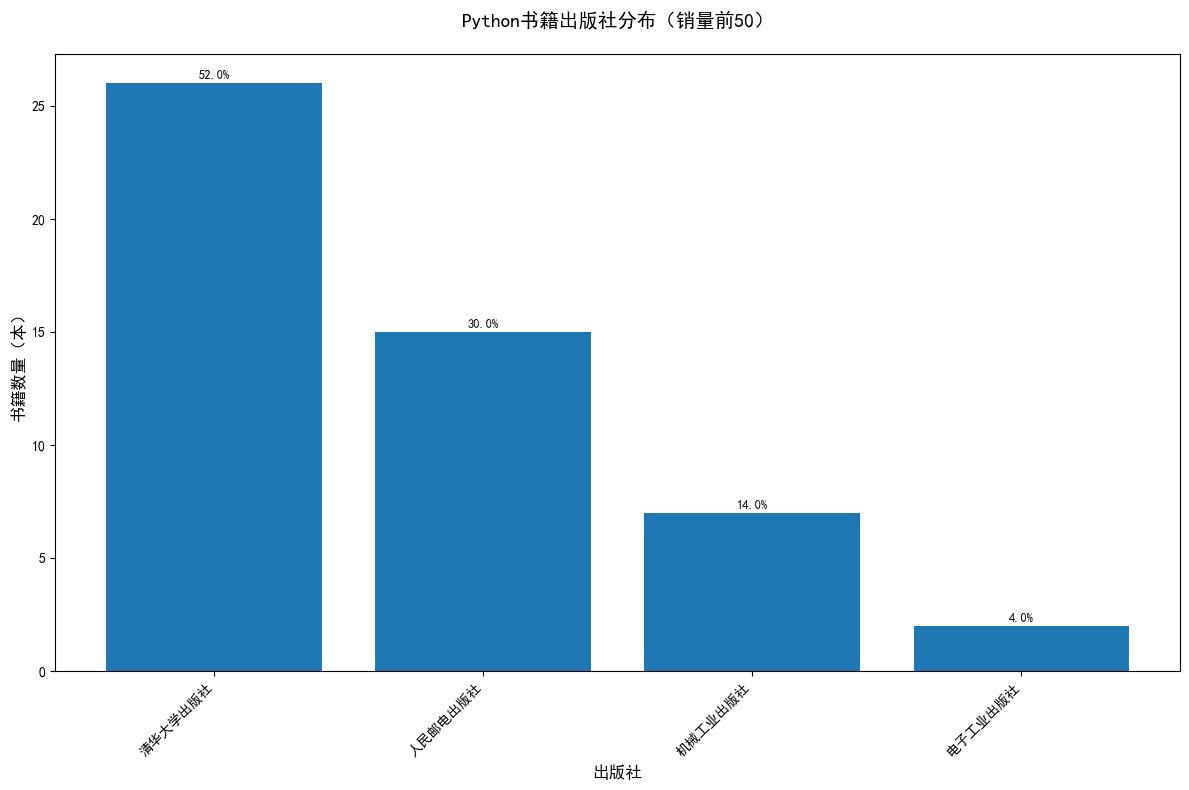

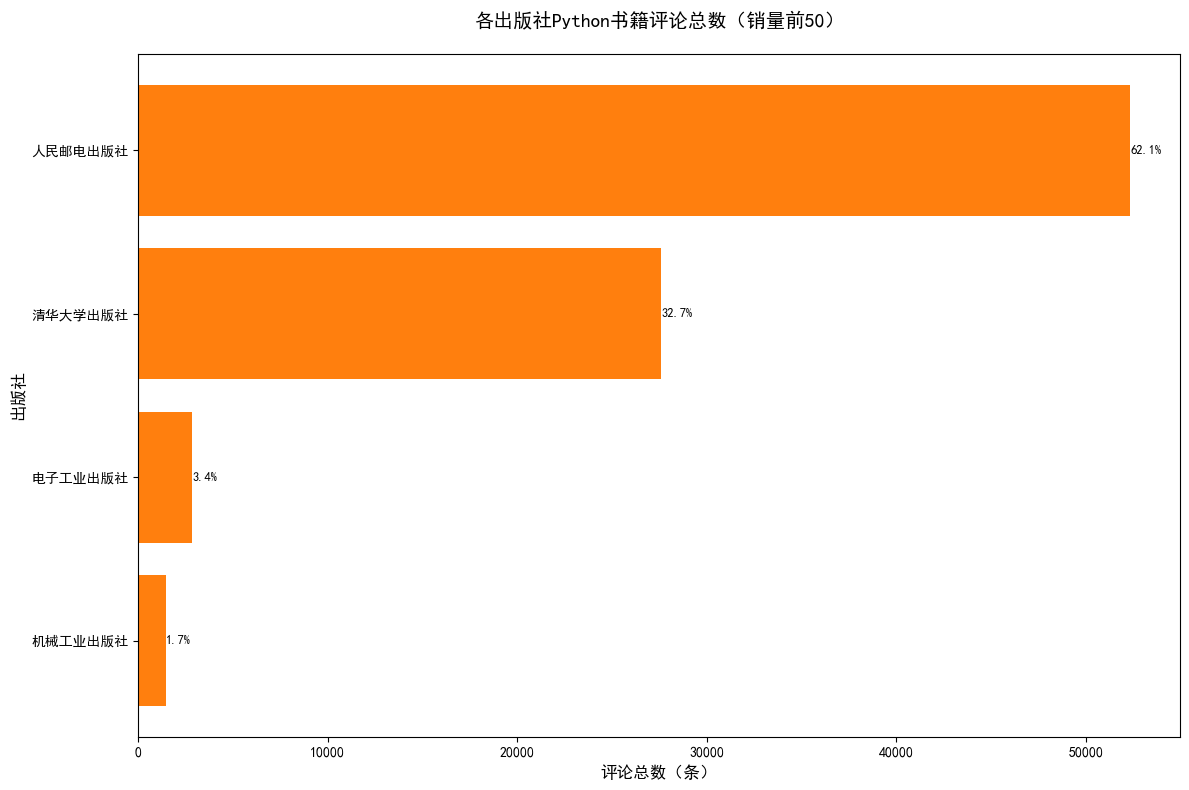

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# -------------------------- 1. 数据读取与预处理 --------------------------
# 设置中文字体（解决中文显示乱码问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 定义文件路径
input_file = r"D:\GitHub\ex_Team01_group_3\dangdang_python_books_clean.csv"
output_dir = r"D:\GitHub\ex_Team01_group_3\output"

# 创建输出目录（如果不存在）
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 读取CSV文件，仅提取指定三列
df = pd.read_csv(
    input_file,
    usecols=['书名', '出版社', '评论数']  # 精准提取目标列
)

# 数据清洗：确保评论数为数值类型，处理缺失值
df['评论数'] = pd.to_numeric(df['评论数'], errors='coerce').fillna(0).astype(int)

# -------------------------- 2. 出版社频率条形图（降序+百分比标注） --------------------------
# 统计出版社出现频率
press_freq = df['出版社'].value_counts()
# 计算百分比
press_pct = (press_freq / press_freq.sum()) * 100

# 创建画布
fig1, ax1 = plt.subplots(figsize=(12, 8))
# 绘制条形图
bars1 = ax1.bar(
    press_freq.index, 
    press_freq.values,
    color='#1f77b4'
)

# 设置标题和标签
ax1.set_title('Python书籍出版社分布（销量前50）', fontsize=14, pad=20)
ax1.set_xlabel('出版社', fontsize=12)
ax1.set_ylabel('书籍数量（本）', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.get_xticklabels(), ha='right')  # 单独设置对齐方式

# 在条形顶端标注百分比
for bar, pct in zip(bars1, press_pct):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,  # x坐标（条形中心）
        height + 0.1,                     # y坐标（条形顶端+偏移）
        f'{pct:.1f}%',                    # 标注文本（保留1位小数）
        ha='center', va='bottom',         # 对齐方式
        fontsize=9
    )

# 调整布局（避免标签被截断）
plt.tight_layout()
# 保存图表到输出目录
fig1.savefig(os.path.join(output_dir, '出版社频率分布.png'), dpi=300, bbox_inches='tight')

# -------------------------- 3. 出版社评论总数水平条形图（降序+百分比） --------------------------
# 按出版社分组，计算评论数总和
press_comment = df.groupby('出版社')['评论数'].sum().sort_values(ascending=False)
# 计算评论数占比
comment_pct = (press_comment / press_comment.sum()) * 100

# 创建画布
fig2, ax2 = plt.subplots(figsize=(12, 8))
# 绘制水平条形图
bars2 = ax2.barh(
    press_comment.index, 
    press_comment.values,
    color='#ff7f0e'
)

# 设置标题和标签
ax2.set_title('各出版社Python书籍评论总数（销量前50）', fontsize=14, pad=20)
ax2.set_xlabel('评论总数（条）', fontsize=12)
ax2.set_ylabel('出版社', fontsize=12)
# 反转y轴（让评论数最高的出版社在顶部）
ax2.invert_yaxis()

# 在条形末端标注百分比
for bar, pct in zip(bars2, comment_pct):
    width = bar.get_width()
    ax2.text(
        width + 5,                        # x坐标（条形末端+偏移）
        bar.get_y() + bar.get_height()/2, # y坐标（条形中心）
        f'{pct:.1f}%',                    # 标注文本
        ha='left', va='center',           # 对齐方式
        fontsize=9
    )

# 调整布局
plt.tight_layout()
# 保存图表到输出目录
fig2.savefig(os.path.join(output_dir, '出版社评论总数分布.png'), dpi=300, bbox_inches='tight')

# -------------------------- 4. 保存分析结果数据 --------------------------
# 整理分析结果为DataFrame
result_df = pd.DataFrame({
    '出版社': press_freq.index,
    '书籍数量': press_freq.values,
    '书籍数量占比(%)': press_pct.values.round(1),
    '评论总数': press_comment.reindex(press_freq.index).fillna(0).astype(int),
    '评论数占比(%)': comment_pct.reindex(press_freq.index).fillna(0).round(1)
})

# 保存结果到CSV文件
result_df.to_csv(
    os.path.join(output_dir, 'Python书籍出版社分析结果.csv'),
    index=False,
    encoding='utf-8-sig'  # 确保中文正常显示
)

# 打印提示信息
print(f"分析完成！结果已保存至：{output_dir}")
print(f"1. 出版社频率分布图：出版社频率分布.png")
print(f"2. 出版社评论总数图：出版社评论总数分布.png")
print(f"3. 分析结果数据：Python书籍出版社分析结果.csv")

**结果解读**

1. 畅销数量排名靠前的清华大学出版社，一定程度上，说明其推出的Python书籍更易进入畅销榜单，市场发行和内容打磨能力更强。
2. 人民邮电出版社的畅销书数量低于清华大学出版社，但是总评论数高于清华大学出版社，说明其书籍内容更易引发读者共鸣、疑问或讨论，可能的原因有：入门类书籍读者提问多，实战类书籍读者分享经验多。这可以给作者写书方向作参考
